In [68]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder 
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import accuracy_score

In [69]:
df = pd.read_csv("file.csv")
print("\nClass Distribution:\n")
print(df["Decision"].value_counts())
X = df.drop("Decision",axis=1)
y = df["Decision"]


Class Distribution:

Decision
Cinema      6
Tennis      2
Stay-in     1
Shopping    1
Name: count, dtype: int64


In [70]:
categorial_features = ["Weather","Parent","Money"]
preprocessor = ColumnTransformer(
    transformers=[
        ("cat" , OneHotEncoder(handle_unknown = 'ignore'), categorial_features)
   ]
)   

In [71]:
pipeline = Pipeline(steps=[
    ("preprocessing",preprocessor),
    ("model",DecisionTreeClassifier(
        criterion = "entropy",
        max_depth=3,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42
    ))

])

In [72]:
pipeline.fit(X,y)
print("\nTraining Accuracy :",pipeline.score(X,y))


Training Accuracy : 0.9


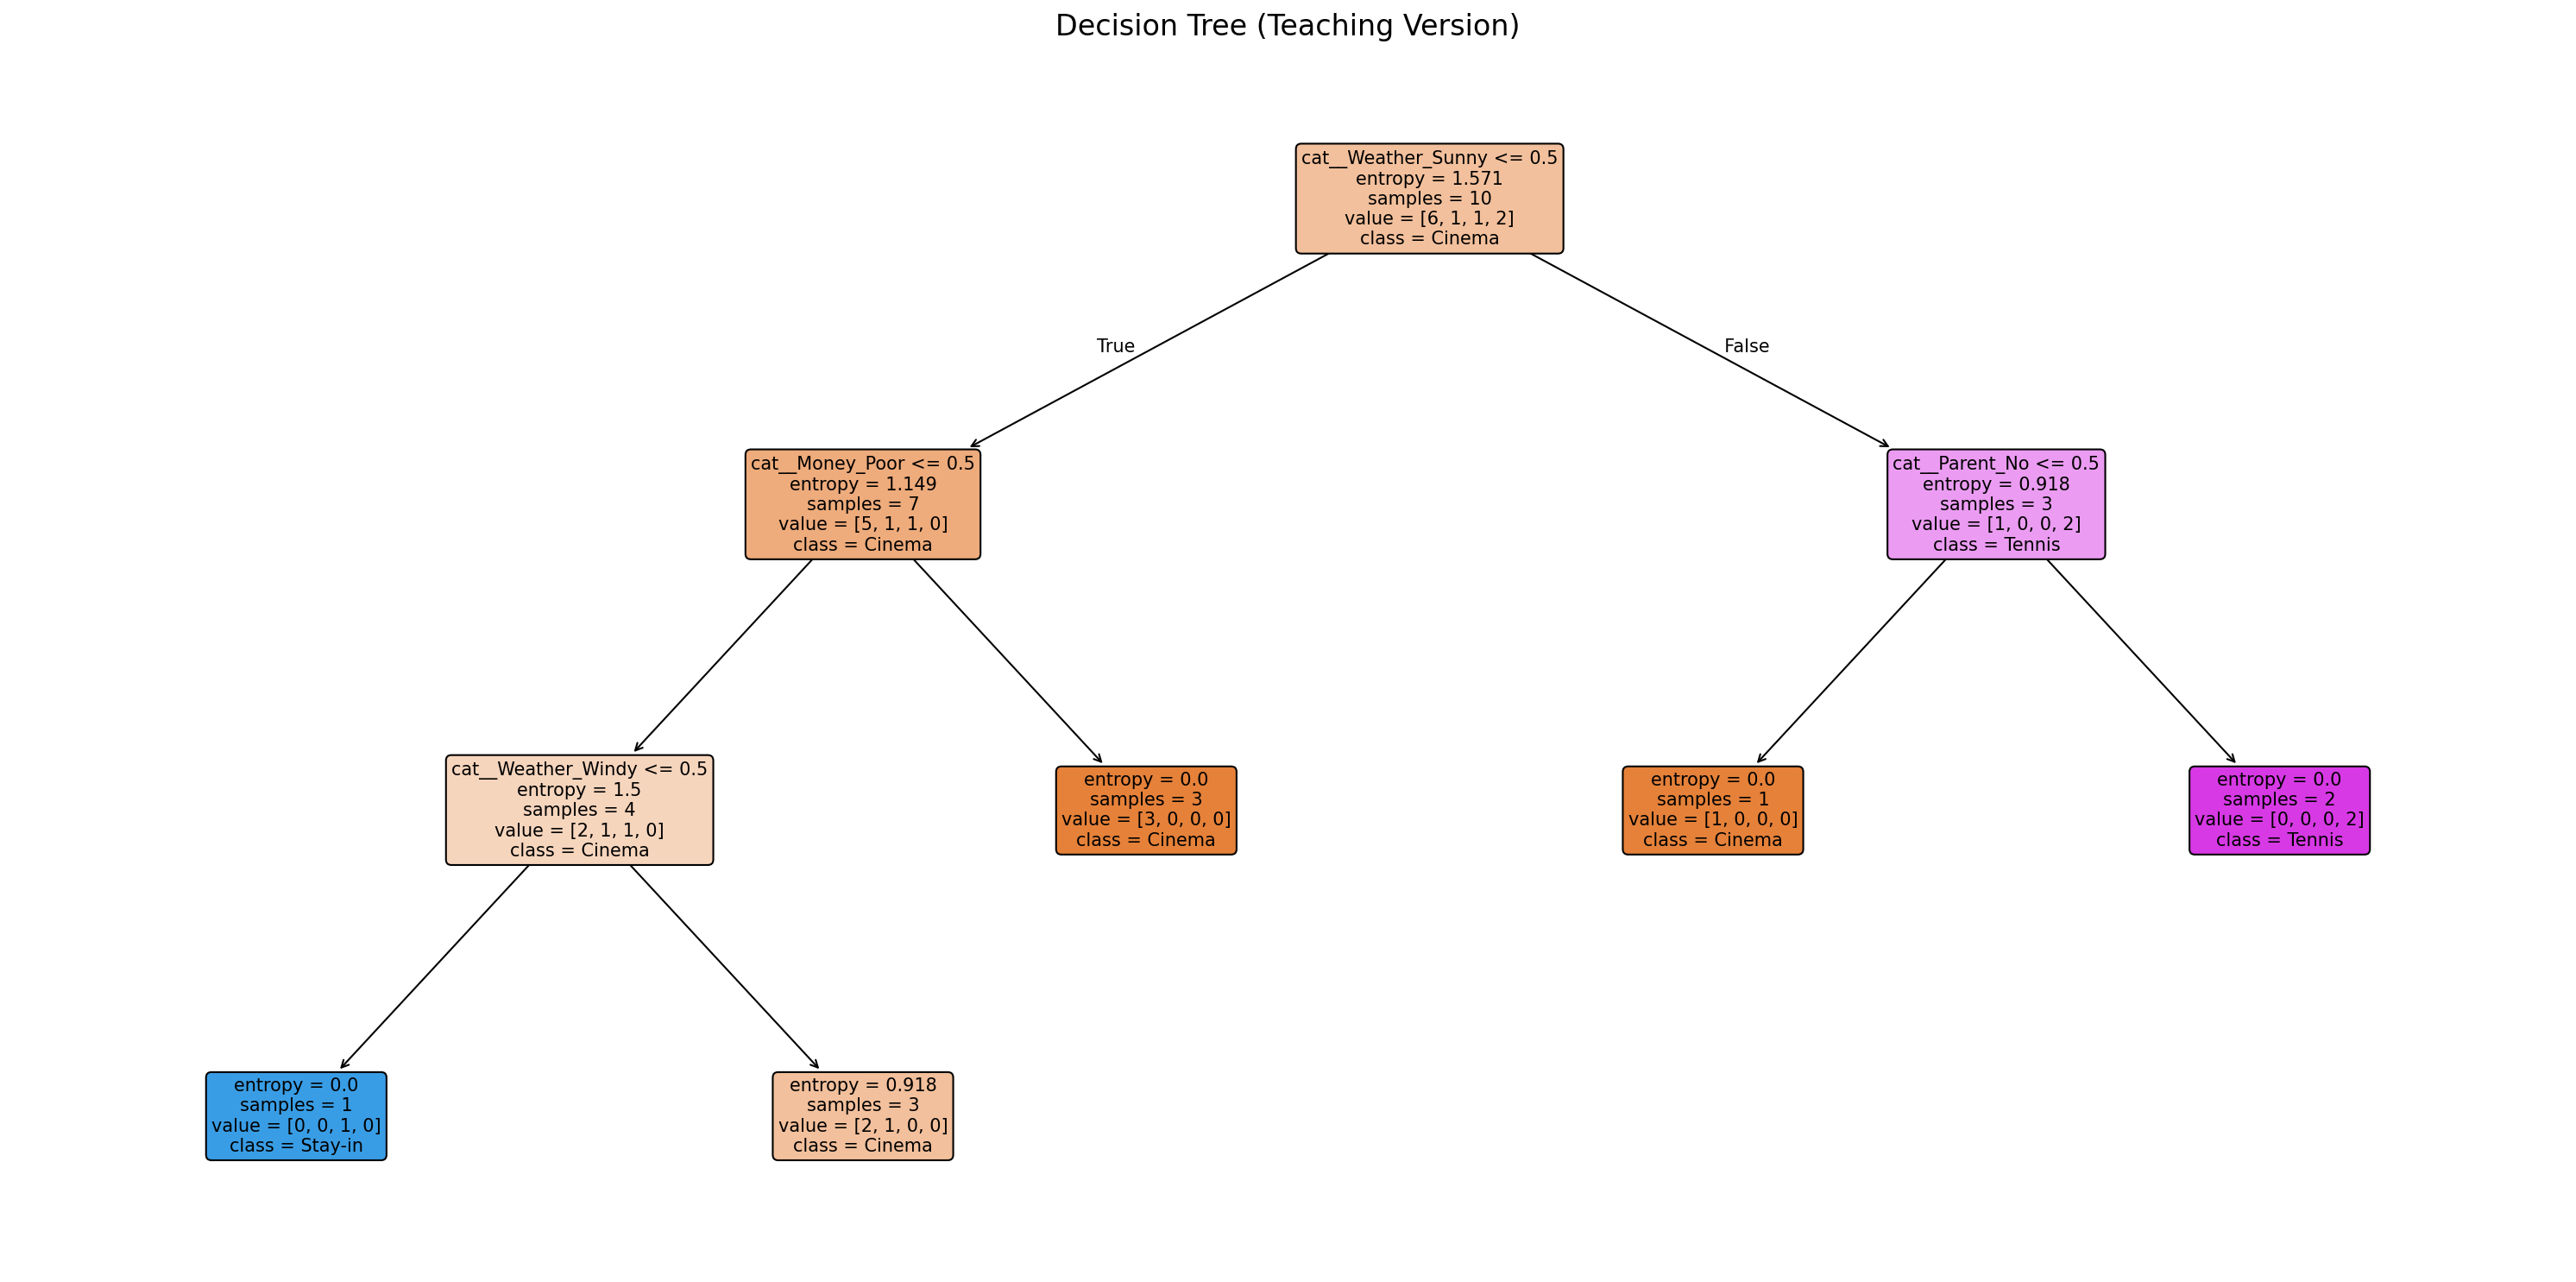

In [73]:
feature_names = pipeline.named_steps["preprocessing"].get_feature_names_out()

plt.figure(figsize=(20,10), dpi=150)

plot_tree(
    pipeline.named_steps["model"],
    feature_names=feature_names,
    class_names=pipeline.named_steps["model"].classes_,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree (Teaching Version)",fontsize=16)
plt.tight_layout()
plt.savefig("clean_decision_tree.png", dpi=300)
plt.show()




In [74]:
def predict_user_input():
    print("\nEnter User Details:")

    weather = input("Weather (Sunny/Windy/Rainy):")
    parent = input("Parent (Yes/No):")
    money = input("Money (Rich/Poor):")

    user_df = pd.DataFrame({
    "Weather" : [weather],
    "Parent": [parent],
    "Money":[money]
    })
    prediction = pipeline.predict(user_df)[0]
    probability = pipeline.predict_proba(user_df)

    print("\nPredicted Decision:",prediction)
    print("CLass Probability:")

    for cls,prob in zip(pipeline.named_steps["model"].classes_,probability[0]):
        print(f"{cls}:{round(prob*100,2)}%")

predict_user_input()      
    


Enter User Details:


Weather (Sunny/Windy/Rainy): Sunny
Parent (Yes/No): YEs
Money (Rich/Poor): Rich



Predicted Decision: Cinema
CLass Probability:
Cinema:100.0%
Shopping:0.0%
Stay-in:0.0%
Tennis:0.0%


In [75]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load your dataset
df = pd.read_csv("DATA.csv")

# Features (input) and Target (output)
X = df[["Weather", "Parent", "Money"]]
y = df["Decision"]


# Split into train (80%) and test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Output sizes
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (88, 3)
Testing data: (22, 3)


In [76]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [77]:
print("\nTrainig Accuracy:",pipeline.score(X,y))


Trainig Accuracy: 0.990909090909091


In [78]:
pred=pipeline.predict(X_test)

In [79]:
acc=accuracy_score(y_test,pred)
acc

1.0